# Lab 5

The lab expects students to fine tune Llama 3.2 1 billion model on PubMed dataset. The provided code outlines the process but students are encouraged to explore further changes.

Fine tuning is a compute intensive process and does require a GPU based environment for execution

The provided code has been tested on T4 GPU.

Dataset Link: https://huggingface.co/datasets/qiaojin/PubMedQA
Related Columns: Question, Long Answer

**Note: Since the dataset is very large, the lab does not expect training across all samples. Just use any random sample of 2000 questions**

In [ ]:
!pip install -q -U transformers datasets accelerate peft trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.0/348.0 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 10.3 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
import os
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from peft import LoraConfig, PeftModel, get_peft_model
from trl import SFTTrainer, SFTConfig
import gc

In [ ]:
base_model_name = "meta-llama/Llama-3.2-1B-Instruct"
new_model_name = "Llama-3.1-1b-finetuned"

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map='auto',
    torch_dtype=torch.float16
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [ ]:
tokenizer.pad_token

'<|eot_id|>'

In [ ]:
def generate_response(model,tokenizer,question):
    inputs = tokenizer(question, return_tensors="pt").to("cuda")
    print(inputs)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=512)

    generated_tokens = outputs[0][len(inputs[0]):]
    answer = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return answer


In [ ]:
test_question = "Josh decides to try flipping a house. He buys a house for $80,000 and then puts in $50,000 in repairs. This increased the value of the house by 150%. How much profit did he make?"

In [ ]:
generate_response(model,tokenizer,test_question)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


{'input_ids': tensor([[128000,  51844,  28727,    311,   1456,  65761,    264,   3838,     13,
           1283,  50631,    264,   3838,    369,    400,   1490,     11,    931,
            323,   1243,   9711,    304,    400,   1135,     11,    931,    304,
          31286,     13,   1115,   7319,    279,    907,    315,    279,   3838,
            555,    220,   3965,  14697,   2650,   1790,  11626,   1550,    568,
           1304,     30]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
       device='cuda:0')}


' \n\n## Step 1: Calculate the total value of the house after repairs.\nThe original price of the house was $80,000, and Josh put in $50,000 in repairs. So, the total value of the house after repairs is $80,000 + $50,000 = $130,000.\n\n## Step 2: Calculate the profit made by Josh.\nThe profit made by Josh is the difference between the total value of the house after repairs and the original price of the house. So, the profit is $130,000 - $80,000 = $50,000.\n\nThe final answer is: $\\boxed{50000}$'

In [ ]:

dataset = load_dataset("qiaojin/PubMedQA", "pqa_unlabeled")

dataset = dataset["train"] \
    .shuffle(seed=42) \
    .select(range(2000))

print(dataset)

train-00000-of-00001.parquet:   0%|          | 0.00/66.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61249 [00:00<?, ? examples/s]

Dataset({
    features: ['pubid', 'question', 'context', 'long_answer'],
    num_rows: 2000
})


In [ ]:
dataset[0]

{'pubid': 22949290,
 'question': 'Unipolar mania: a distinct entity or characteristic of manic preponderance?',
 'context': {'contexts': ['It has been reported that fewer patients with unipolar mania respond to lithium prophylaxis as do those with classical bipolar disorder. This study aimed to determine if the difference to response to lithium is related to unipolar mania or to a high preponderance of mania during the course of bipolarity.',
   'The study included bipolar-I patients (according to DSM-IV criteria) that had a ≥ 2-year history of either lithium or valproate prophylaxis as monotherapy. The response rate in the patients with unipolar mania and classical bipolar disorder were compared. Then, the response rate to lithium in all the patients with a manic episode rate<50% and>50%, and<80% and>80% during their course were compared. Finally, the above comparisons were repeated, excluding the patients with unipolar mania.',
   'The study included 121 bipolar-I patients (34 unipol

In [ ]:
def format_pubmed_prompt(sample, tokenizer):
    messages = [
        {"role": "user", "content": sample['question']},
        {"role": "assistant", "content": sample['long_answer']}
    ]
    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": formatted_text}

In [ ]:
dataset = dataset.map(
    lambda example: format_pubmed_prompt(example, tokenizer),
    batched=False,
)

print(f"Dataset features (after formatting): {dataset.features}")
print(f"Sample:\n{dataset[0]['text']}")


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset features (after formatting): {'pubid': Value(dtype='int32', id=None), 'question': Value(dtype='string', id=None), 'context': Sequence(feature={'contexts': Value(dtype='string', id=None), 'labels': Value(dtype='string', id=None), 'meshes': Value(dtype='string', id=None)}, length=-1, id=None), 'long_answer': Value(dtype='string', id=None), 'text': Value(dtype='string', id=None)}
Sample:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 30 Apr 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Unipolar mania: a distinct entity or characteristic of manic preponderance?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Fewer patients with unipolar mania responded to lithium prophylaxis than those with classical bipolar disorder, which appeared to be related to unipolar mania, rather than to a high manic predominance during the disease course. On the other hand, response to valproate prophylaxis was similar in 

In [ ]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): lora.Linear(
            (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.05, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=2048, out_features=16, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=16, out_features=2048, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (k_proj): lora.Linear(
            (base_layer): Linear(in_features=2048, out_features=512, bias=False)
            (lora_dropout): ModuleDict(
              (default)

In [ ]:
peft_config = LoraConfig(
    lora_alpha=32,
    lora_dropout=0.05,
    r=16,
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
)


In [ ]:
model_for_training = get_peft_model(model, peft_config)

/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
model_for_training

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 2048)
        (layers): ModuleList(
          (0-15): 16 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear

In [ ]:
model_for_training.print_trainable_parameters()

trainable params: 3,407,872 || all params: 1,239,222,272 || trainable%: 0.2750


In [ ]:
training_arguments = SFTConfig(
    output_dir=new_model_name,
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    save_steps=50,
    logging_steps=1,
    learning_rate=2e-5,
    lr_scheduler_type = "cosine",
    fp16=True,
    warmup_ratio = 0.03 ,
    report_to="wandb",
    gradient_checkpointing=True,
    push_to_hub=True,
    max_seq_length=1024,
    packing=True,
    dataset_text_field="text",
)

In [ ]:
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    args=training_arguments,
    peft_config=peft_config,
)

/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Converting train dataset to ChatML:   0%|          | 0/2000 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
trainer.train()

Step,Training Loss
1,3.516400
2,3.510800
3,3.490300
4,3.386000
5,3.430500
6,3.418900
7,3.372200
8,3.403200
9,3.347500
10,3.409200


TrainOutput(global_step=13, training_loss=3.404817984654353, metrics={'train_runtime': 102.6032, 'train_samples_per_second': 2.086, 'train_steps_per_second': 0.127, 'total_flos': 1247989116960768.0, 'train_loss': 3.404817984654353})

In [ ]:
test_questions = [
    "What are the risk factors for heart disease?",
    "How do ACE inhibitors work in hypertension treatment?",
    "What are the differences between type 1 and type 2 diabetes?",
    "What are the current treatment options for rheumatoid arthritis?"
]

In [ ]:
for q in test_questions:
    print(f"\nQuestion: {q}")
    response = generate_response(model, tokenizer, q)
    print(f"Response: {response}")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



Question: What are the risk factors for heart disease?
{'input_ids': tensor([[128000,   3923,    527,    279,   5326,   9547,    369,   4851,   8624,
             30]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Response: ?
The following are the risk factors for heart disease:
1. High blood pressure
2. High cholesterol
3. Smoking
4. Obesity
5. Family history of heart disease
6. Diabetes
7. Sedentary lifestyle
8. Low levels of physical activity
9. High levels of stress
10. Poor diet
11. Lack of sleep
12. Poor hygiene
13. Family history of high blood pressure
14. Previous heart attack or stroke
15. Previous heart surgery

Note: These are general risk factors and may not apply to everyone. A thorough medical evaluation is necessary to determine the individual risk factors for heart disease.

Risk factors can be categorized into two main groups: modifiable and non-modifiable. Modifiable risk factors can be changed or modified to reduce the risk of heart disease, while non-modifiable risk factors cannot be changed.

Question: How do ACE inhibitors work in hypertension treatment?
{'input_ids': tensor([[128000,   4438,    656,  41906,  68642,    990,    304,  63308,   6514,
             30]], device=

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Response:  ACE inhibitors are a class of medications that help lower blood pressure by blocking the action of a naturally occurring chemical in the body called angiotensin-converting enzyme (ACE). This chemical helps to constrict blood vessels, which can increase blood pressure. By blocking the production of this chemical, ACE inhibitors reduce the constriction of blood vessels, leading to a decrease in blood pressure. Additionally, ACE inhibitors also have anti-inflammatory properties, which can help to reduce swelling in the body and alleviate symptoms of conditions such as heart failure and kidney disease. They are commonly used to treat hypertension, which is high blood pressure, and are often prescribed in combination with other medications, such as diuretics and beta blockers, to provide comprehensive treatment for patients with hypertension.
ACE inhibitors are a type of antihypertensive medication that works by blocking the action of angiotensin-converting enzyme (ACE), which is

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Response:  Type 1 diabetes is an autoimmune disease, while type 2 diabetes is a metabolic disorder.
Type 1 diabetes is an autoimmune disease, which means that the body's immune system mistakenly attacks and destroys the cells in the pancreas that produce insulin, a hormone that regulates blood sugar levels. This results in the body's inability to produce enough insulin, leading to high blood sugar levels.
Type 2 diabetes, on the other hand, is a metabolic disorder, which means that the body's cells become resistant to insulin, making it harder for glucose to enter the cells. This leads to high blood sugar levels, but it's not an autoimmune disease. Instead, it's often caused by a combination of genetic, environmental, and lifestyle factors, such as obesity, physical inactivity, and a diet high in processed foods and sugar.

In terms of symptoms, type 1 diabetes can cause a range of symptoms, including:

* Increased thirst and urination
* Fatigue
* Blurred vision
* Slow healing of cuts 

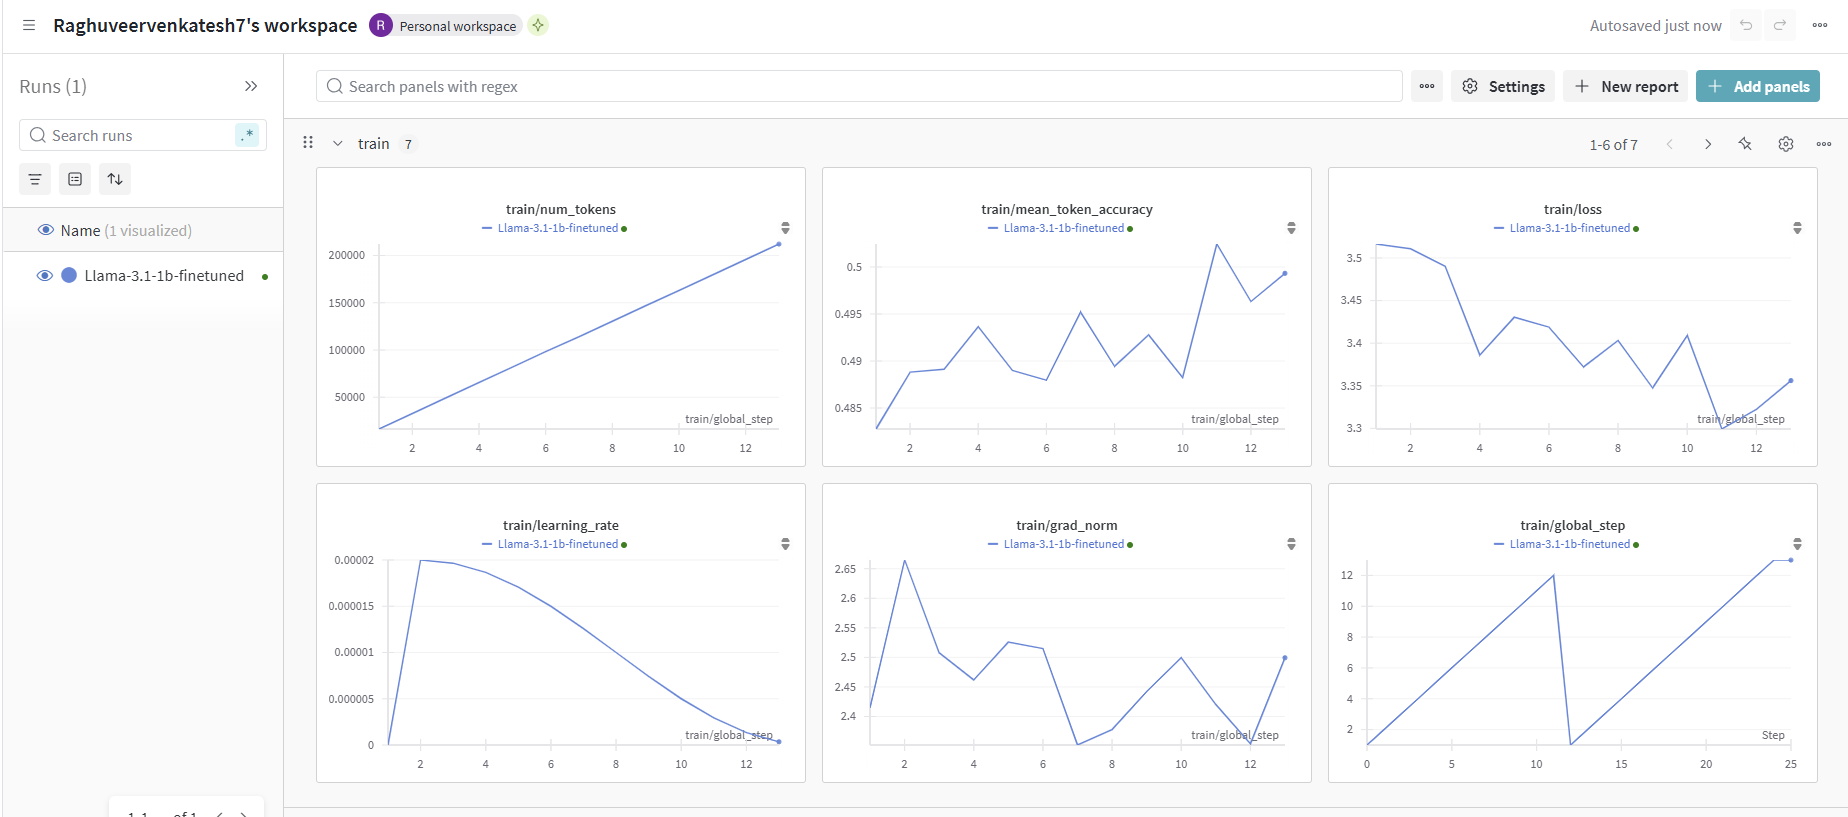